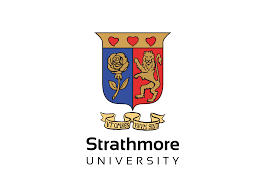

<p style="text-align: center;"><font size="6"> <font color = "purple"> Training a Convolutional Neural Network that
classifies whether a Patient has Pneumonia or not </p>

<p style="text-align: center;"><font size="4">Samuel Irungu Kigotho</font></p>
<p style="text-align: center;"><font size="4">Adm No: 169124</font></p>
<p style="text-align: center;"><font size="4">Assigment: Convolutional Neural Networks</font></p>
<p style="text-align: center;"><font size="4">DSA 8401: Applied Machine Learning</font></p>
<p style="text-align: center;"><font size="4">Master in Data Science and Analytic</font></p>

## Background information 

<p style='text-align: justify;'> Convolutional Neural Networks (CNNs) are specialized neural networks designed for grid-like data, such as images. They work by using small filters that slide over the image, detecting local patterns like edges or textures through a process called convolution. These patterns are captured in feature maps, and a non-linear activation function (like ReLU) helps the network learn complex features. Pooling layers then reduce the size of these feature maps, preserving important information while making the model efficient. As the network deepens, it identifies more abstract features, progressing from simple shapes to complex objects. Finally, the fully connected layers at the end classify the image based on the learned features. CNNs are powerful because they efficiently detect patterns, are translation-invariant, and build a spatial hierarchy of features, making them ideal for tasks like image recognition, object detection, and medical imaging. <p> 

## Summary of the dataset

<p style='text-align: justify;'>
In this activity we will use a data set with x-ray images to train a convolutional neural network that
classifies whether the patient has pneumonia or not. The description of the data set can be found at
the following link:
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia. <p>

 ## Use Keras to load the dataset

In [38]:
# Load the modules needed
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from tensorflow . keras . preprocessing . image import ImageDataGenerator, load_img
import matplotlib . pyplot as plt
%matplotlib inline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization

In [39]:
# Define the dataset base path (update this to your local dataset path)
basepath = "E:/chest_xray"
classes = ["NORMAL", "PNEUMONIA"]

# Initialize a dictionary to store image file names for each class
images = {}

# Loop through each class and read file names
for c in classes:
    class_path = os.path.join(basepath, "train", c)  # Path to the class folder
    if os.path.exists(class_path):  # Check if the path exists
        images[c] = os.listdir(class_path)
        print(f"Number of training images in the class {c}: {len(images[c])}")
    else:
        print(f"Directory does not exist: {class_path}")

Number of training images in the class NORMAL: 1341
Number of training images in the class PNEUMONIA: 3875


In [40]:
img_path = os.path.join(basepath, "train", c, images[c][j])
print(f"Checking image path: {img_path}")
img = load_img(img_path)

Checking image path: E:/chest_xray\train\PNEUMONIA\person1310_bacteria_3302.jpeg


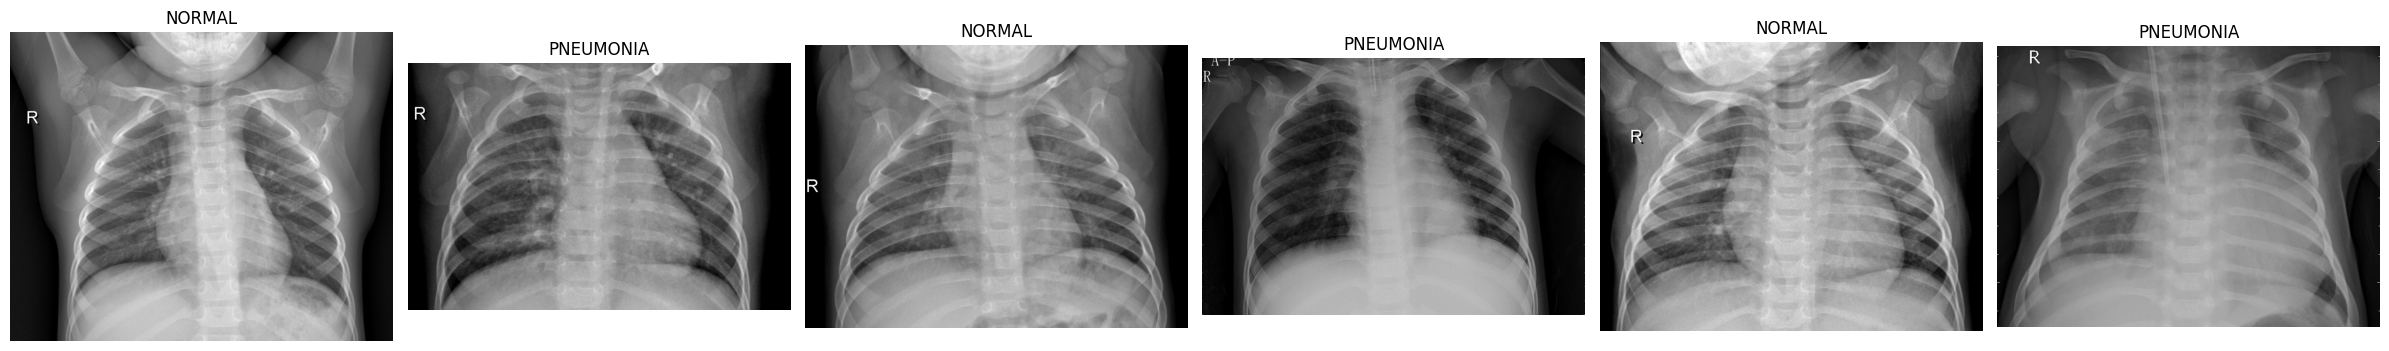

In [41]:
# Display images
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(24, 8))
for l in range(3):  # Loop through three sets of images
    for i, c in enumerate(classes):  # Loop through classes
        try:
            j = np.random.randint(len(images[c]))  # Random image index
            img_path = os.path.join(basepath, "train", c, images[c][j])
            img = load_img(img_path)  # Load image
            ax[l * 2 + i].imshow(img, cmap="gray")  # Display image
            ax[l * 2 + i].set_title(f"{c}")  # Set title
            ax[l * 2 + i].axis("off")  # Turn off axes
        except IndexError:
            print(f"No images found for class {c}. Skipping...")
        except Exception as e:
            print(f"Error loading image: {e}")

plt.tight_layout()
plt.show()

In [42]:
# Define constants
batch_size = 32
img_size = (150, 150)

# Initialize ImageDataGenerator for training and testing
datagen_train = ImageDataGenerator(rescale=1.0 / 255, horizontal_flip=True)
datagen_test = ImageDataGenerator(rescale=1.0 / 255)

# Define paths
train_dir = os.path.join(basepath, "train")
test_dir = os.path.join(basepath, "test")

# Load training set
training_set = datagen_train.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="binary",  # Use binary for two classes (NORMAL, PNEUMONIA)
)

# Load test set
test_set = datagen_test.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="binary",
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Summary of the training set

In [43]:
# Print summary of the training set
print(f"Number of samples in training set: {training_set.samples}")
print(f"Batch size: {training_set.batch_size}")
print(f"Number of classes: {training_set.num_classes}")
print(f"Class labels: {training_set.class_indices}")
print(f"Number of batches per epoch: {training_set.samples // training_set.batch_size}")

Number of samples in training set: 5216
Batch size: 32
Number of classes: 2
Class labels: {'NORMAL': 0, 'PNEUMONIA': 1}
Number of batches per epoch: 163


## Create a model trying different architectures (number of layers, number of neurons, filters,pooling layers, etc.).

## Simple CNN Architecture
This model has a basic structure with a couple of convolutional layers followed by max-pooling layers and a fully connected layer.

In [44]:
def simple_cnn(input_shape=(150, 150, 1)):
    model = Sequential()
    
    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Flatten and Dense Layer
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Dropout for regularization
    model.add(Dense(1, activation='sigmoid'))  # Binary classification output
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and summarize the model
model = simple_cnn()
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)                   │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_30 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,635,905 (40.57 MB)

 Trainable params: 10,635,905 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

## Deeper CNN with More Filters
This model uses more convolutional layers with additional filters to capture more complex patterns. It also includes batch normalization layers to speed up training and improve generalization.


In [29]:
def deeper_cnn(input_shape=(150, 150, 1)):
    model = Sequential()
    
    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Flatten and Dense Layer
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and summarize the model
model = deeper_cnn()
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       9,470,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,564,033 (36.48 MB)

 Trainable params: 9,563,585 (36.48 MB)

 Non-trainable params: 448 (1.75 KB)

## Wider CNN with Larger Dense Layer
This model explores the idea of using more neurons in the fully connected (dense) layer to allow the network to learn more complex representations.

In [30]:
def wider_cnn(input_shape=(150, 150, 1)):
    model = Sequential()
    
    # First Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Flatten and Dense Layer
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Output layer
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and summarize the model
model = wider_cnn()
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 148, 148, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 74, 74, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 72, 72, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 36, 36, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 165888)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │      84,935,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 85,010,177 (324.29 MB)

 Trainable params: 85,010,177 (324.29 MB)

 Non-trainable params: 0 (0.00 B)

## Very Deep CNN (More Layers)
This is a more advanced architecture with several convolutional layers, pooling, and dense layers. It is more complex and computationally expensive.

In [32]:
def very_deep_cnn(input_shape=(150, 150, 1)):
    model = Sequential()
    
    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Fourth Convolutional Block
    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Fifth Convolutional Block
    model.add(Conv2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Flatten and Dense Layer
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Output layer
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and summarize the model
model = very_deep_cnn()
model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 148, 148, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │           1,025 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,667,201 (13.99 MB)

 Trainable params: 3,667,201 (13.99 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer Learning with Pre-trained CNN (e.g., VGG16)
If you want to use a pre-trained model for transfer learning, VGG16 is a popular choice. This allows the model to leverage knowledge from large datasets like ImageNet.

In [35]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

def transfer_learning_cnn(input_shape=(150, 150, 3)):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    model = Sequential()
    
    # Add pre-trained VGG16 layers
    model.add(base_model)
    model.add(GlobalAveragePooling2D())
    
    # Fully Connected Layer
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Output layer
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and summarize the model
model = transfer_learning_cnn()
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 14,977,857 (57.14 MB)

 Non-trainable params: 0 (0.00 B)

## Train different models and evaluate. Analize which one perform better.

In [45]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# Function to train and evaluate each model
def train_and_evaluate(model, training_set, test_set, epochs=10):
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # Train the model
    history = model.fit(
        training_set,
        steps_per_epoch=training_set.samples // training_set.batch_size,
        epochs=epochs,
        validation_data=test_set,
        validation_steps=test_set.samples // test_set.batch_size,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model
    loss, accuracy = model.evaluate(test_set)
    print(f"Test loss: {loss}")
    print(f"Test accuracy: {accuracy}")
    
    # Return the history for further analysis
    return history, loss, accuracy

# simple CNN model
history_simple_cnn, loss_simple_cnn, acc_simple_cnn = train_and_evaluate(simple_cnn(), training_set, test_set)

# # deeper CNN model
# history_deeper_cnn, loss_deeper_cnn, acc_deeper_cnn = train_and_evaluate(deeper_cnn(), training_set, test_set)

# #  wider CNN model
# history_wider_cnn, loss_wider_cnn, acc_wider_cnn = train_and_evaluate(wider_cnn(), training_set, test_set)

# #  very deep CNN model
# history_very_deep_cnn, loss_very_deep_cnn, acc_very_deep_cnn = train_and_evaluate(very_deep_cnn(), training_set, test_set)

# # transfer learning CNN model
# history_transfer_learning, loss_transfer_learning, acc_transfer_learning = train_and_evaluate(transfer_learning_cnn(input_shape=(150, 150, 3)), training_set, test_set)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.8013 - loss: 0.5239 - val_accuracy: 0.8405 - val_loss: 0.4017
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 0.3823
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.9540 - loss: 0.1232 - val_accuracy: 0.7566 - val_loss: 0.9835
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6250 - val_loss: 1.8598
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9582 - loss: 0.1077 - val_accuracy: 0.7385 - val_loss: 1.3056
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 484ms/step - accuracy: 0.8387 - loss: 0.4011
Test loss: 0.40121975541114807
Test accuracy: 0.8381410241127014


## Plot Training History (Loss and Accuracy)
After training the models, we can visualize their performance during training by plotting the loss and accuracy curves. This helps to identify which model performs the best on both training and validation data.

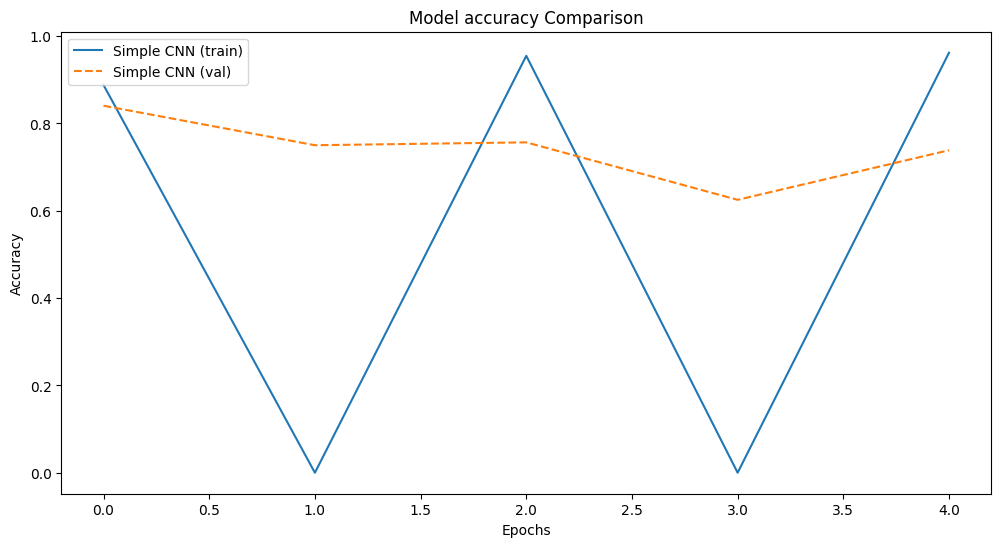

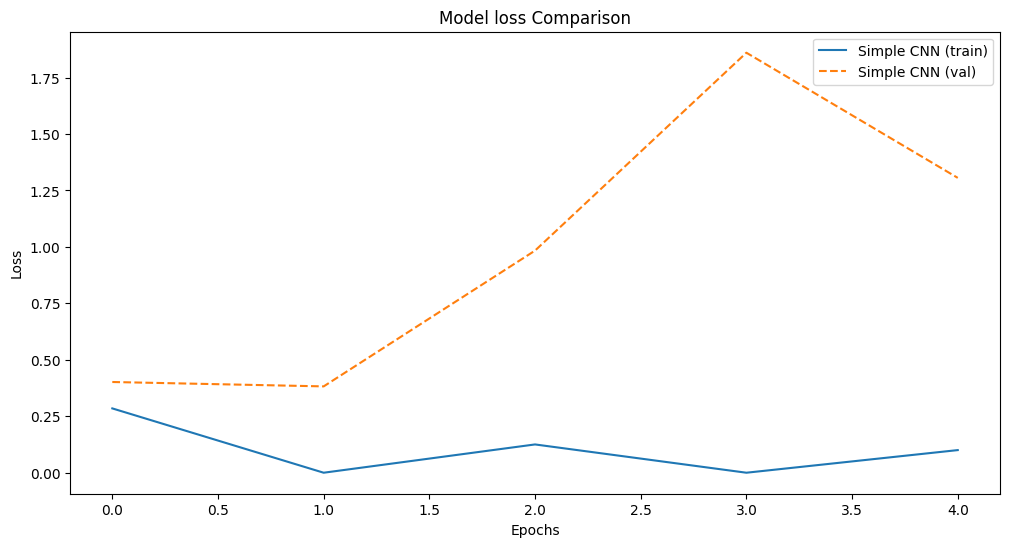

In [46]:
def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(12, 6))
    
    for name, history in histories.items():
        plt.plot(history.history[key], label=f'{name} (train)')
        plt.plot(history.history[f'val_{key}'], label=f'{name} (val)', linestyle='--')
    
    plt.title(f'Model {key} Comparison')
    plt.xlabel('Epochs')
    plt.ylabel(f'{key.capitalize()}')
    plt.legend()
    plt.show()

# Collect all training histories
histories = {
    'Simple CNN': history_simple_cnn,
}

# Plot accuracy and loss for comparison
plot_history(histories, key='accuracy')
plot_history(histories, key='loss')
